---
title: "Bar Charts"
subtitle: "DS 2023 | Communicating with Data"
---

:::{image}https://ontoligentdesign.com/ds2023/images/bar-chart.png
:width: 500px
:align: left
:::

## Overview

A bar chart (or bar graph) is a data visualization that uses  rectangular bars to represent and compare **numerical** data across different **categories**. 

**Categories** are the groups being compared (e.g., product types, months, or cities). These are usually represented on the x axis.

**Values** are the numerical data (e.g., sales numbers, temperatures, or percentages). These are usually represented on the y axis.

The **height** (or length) of each bar is proportional to the value it represents. 

Note the the **width** of the bar has no relationship to the value the bar represents.

## Use Cases

- **Compare a measurement variable over a grouping variable**, for example revenue by region, headcount per department, medals won by country, average rent in five cities, or votes per candidate.

- **Rank items from largest to smallest**, for example a company's top ten customers by spend, most common causes of support tickets, bestselling book titles, or the leading sources of a country's emissions.

- **Compar a measurement variable over two or more grouping variables**, for example quarterly revenue split by product line, survey answers by response option, budget by spending category across several years, or population by age band in each country.

- **Show deviation above and below a baseline with diverging bars**, for example actual vs. budgeted spend per team, temperature anomalies by year, net sentiment scores by topic, or percentage change in sales by store.

- **Compare values across a small number of discrete time periods**, for example annual profit for the last five years, quarterly enrollment, or headcount at the end of each fiscal year. In this case, time periods act as grouping variables.

## Creating a bar chart from scratch

We start with a data frame that contains a grouping variable with unique values and an associated measurement. 

This is the simplest form of data that can be visualized with a bar chart.

In this case, a bar chart will show us visually the differences in magnitude among the values $A$, $B$, an $C$ for the nominal feature.
First, let's acquire the data.

In this case, we'll just make them up.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
my_data = [
	['A', 15],
	['B', 34],
	['C', 22]
]
df1 = pd.DataFrame(my_data)
df1

,group,measure
0,A,15
1,B,34
2,C,22


Before we plot anything, let's properly label the axes in the data frame.

We will call the features `group` and `measure`.

> [!tip] It is highly recommended that you label your data frames before you plot their since these labels will be used by the visualization tool.

In [5]:
df1.columns = ['group', 'measure']
df1

,group,measure
0,A,15
1,B,34
2,C,22


Because the group data are unique, we can create a rudimentary bar chart just by converting the measurement value into a string.

In [9]:
for i, row in df1.iterrows():
    print(row['group'], row['measure'] * '|')

A |||||||||||||||
B ||||||||||||||||||||||||||||||||||
C ||||||||||||||||||||||


We can improve the display by using the block character █ instead of a pipe:

In [10]:
for i, row in df1.iterrows():
    print(row['group'], row['measure'] * '█')

A ███████████████
B ██████████████████████████████████
C ██████████████████████


## Using Pandas' `plot` method

Now, to produce this kind of chart we call Pandas' `.plot()` method and pass it the argument `kind = 'bar'` along with passing features to the `x` and `y` axes of the plot.

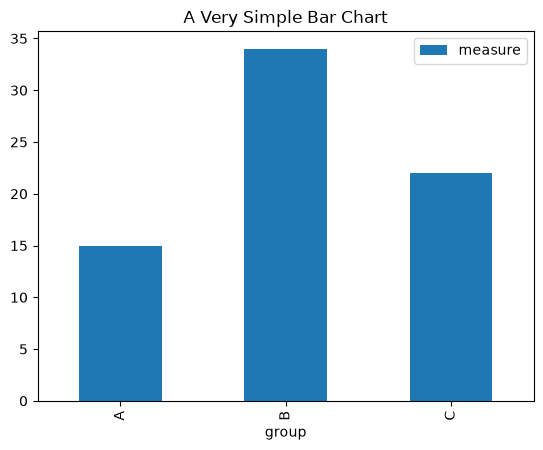

In [11]:
df1.plot(kind='bar', x='group', y='measure', title="A Very Simple Bar Chart")
plt.show()

Stop and inspect the resulting chart. 

Note where each element of the data frame lands on the chart:

- group name $\rightarrow$ x axis label
- group domain $\rightarrow$ x axis scale
- group values $\rightarrow$ positions of bars on x axis
  
- measure name $\rightarrow$ the legend
- measure domain $\rightarrow$ y axis scale
- measure values $\rightarrow$ height of bars on y axis


Let's clean the figure up a bit. 

First, let's remove the legend since it is not really needed in this example.

Second, let's rotate the letters on the x axis for readability.

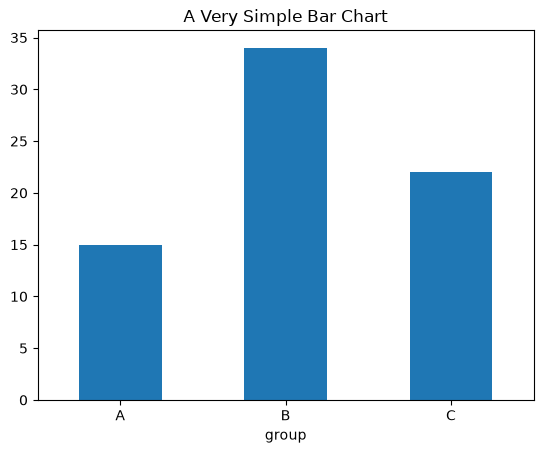

In [15]:
df1.plot(kind='bar', x='group', y='measure', 
         title="A Very Simple Bar Chart", 
         legend=False, rot=0)
plt.show()

To create a horizontal chart, we set `kind` to `barh`.

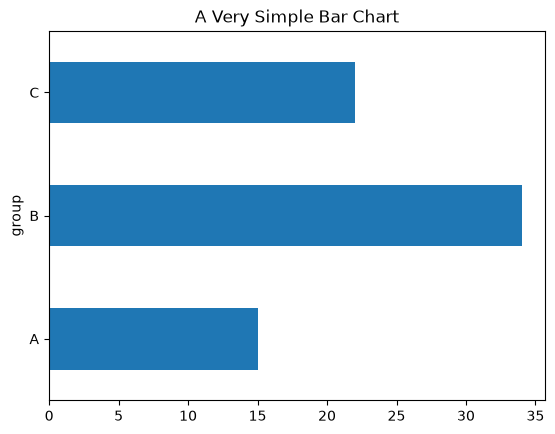

In [17]:
df1.plot(kind='barh', x='group', y='measure', title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

Note that instead of using the argument `kind`, we can call `bar` and `barh` as chained methods to `.plot()`, like so:


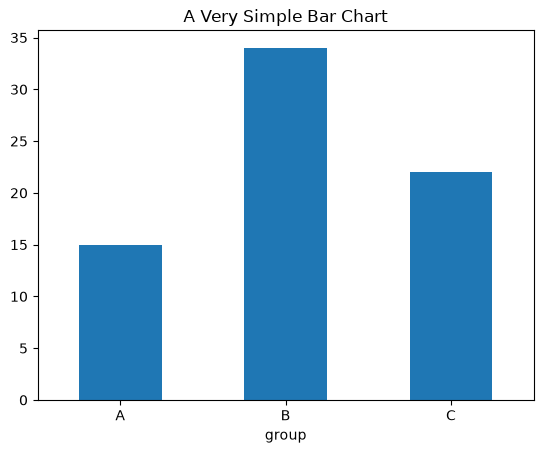

In [18]:
df1.plot.bar(x='group', y='measure', title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

## Plotting with indexes

Note that if we do not set the value of `x`, Pandas will use the index as the x axis.

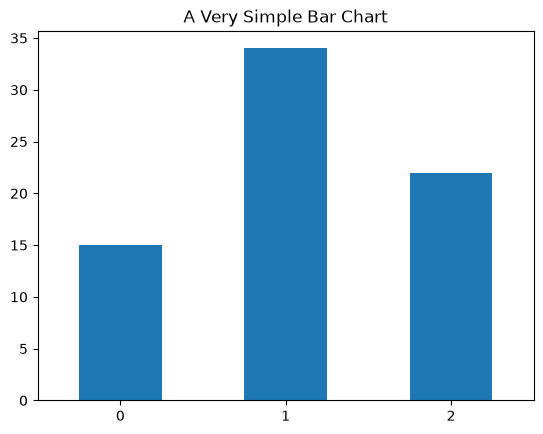

In [20]:
df1.plot.bar(y='measure', title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

In fact, it is a good practice to assign the categorical feature to be the index in this case.

Since the values are unique, they can used as index values. 

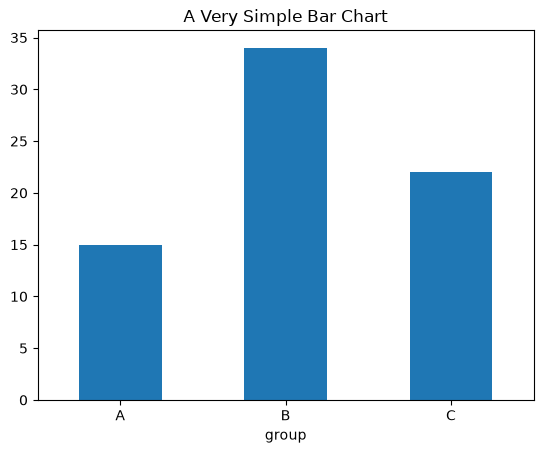

In [22]:
df2 = df1.set_index('group')
df2.plot.bar(y='measure', title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

Note also that if we pass a series to the plot method, by selecting a feature, we don't need to specify the `y` argument either.

In [23]:
df2['measure']

group
A    15
B    34
C    22
Name: measure, dtype: int64

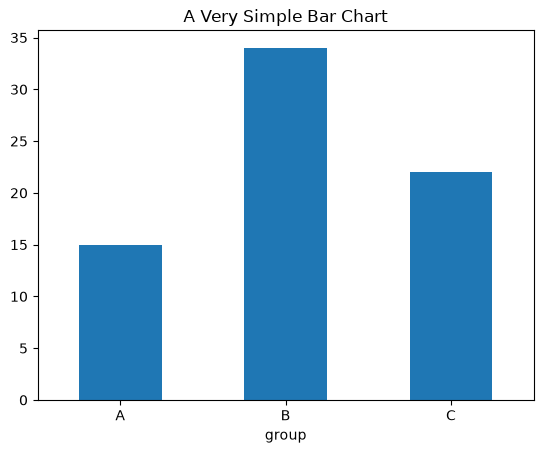

In [24]:
df2['measure'].plot.bar(title="A Very Simple Bar Chart", legend=False, rot=0)
plt.show()

:::{tip}

This is an important pattern to remember: selecting and shaping your data before visualization often makes the visualization code simpler.

:::

## A better example

In the preceding example we had a data set in which unique categorical feaatures are paired with numberic values.

In reality, we don't often get data like this. More typically, the nominal values are repeated over observations.

Consider the Iris data set, which we will grab from the Seaborn library.

In [25]:
iris = sns.load_dataset('iris')
iris.columns = [col.lower().replace(".", "_") for col in iris.columns]
iris.sample(10)

,sepal_length,sepal_width,petal_length,petal_width,species
106,4.9,2.5,4.5,1.7,virginica
89,5.5,2.5,4.0,1.3,versicolor
13,4.3,3.0,1.1,0.1,setosa
149,5.9,3.0,5.1,1.8,virginica
65,6.7,3.1,4.4,1.4,versicolor
97,6.2,2.9,4.3,1.3,versicolor
80,5.5,2.4,3.8,1.1,versicolor
41,4.5,2.3,1.3,0.3,setosa
137,6.4,3.1,5.5,1.8,virginica
143,6.8,3.2,5.9,2.3,virginica


Notice the repetition of the grouping variable `species`.

To plot this variable against any of the other measurements, we need to **group** the measurements by the grouping variable and compute an **aggregate** value, such as the median, sum, or mean of the feature for each group.

To do this, we can use `.groupby()` as follows.

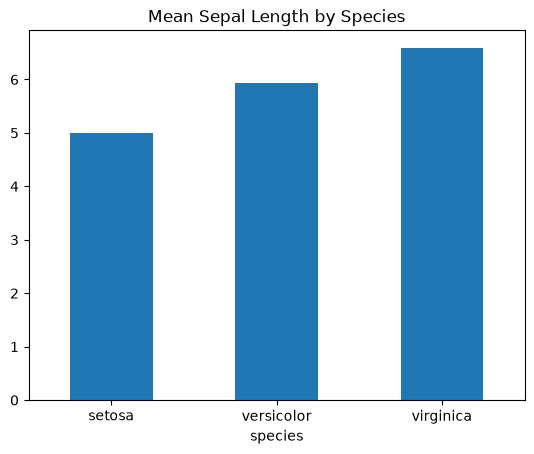

In [30]:
(
    iris.groupby(['species']).sepal_length.mean()
    .plot.bar(rot=0, title="Mean Sepal Length by Species")
)
plt.show()

Another thing we can do is just get the number of instances of a particular value in the nominal column using `.value_counts()`.

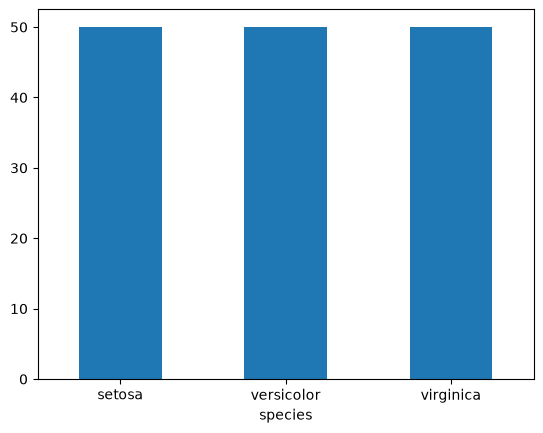

In [31]:
iris.species.value_counts().plot.bar(rot=0)
plt.show()

Here we can see that the data set is balanced over species &mdash; there are $50$ observations per species.

## Showing multiple categories

What if we want to compare the magnitudes of more than one measurement across a grouping variable, in this case `species`?

Let's experiment to find out. 

First, we get the mean of all the measurements by grouping on species and not specifying any columns to aggregate. Pandas will interpret this as saying you want _all_ the columns aggregated. 

> [!Note] You should only do this if the columns are all numeric and come from the same domain.

In [33]:
iris_means = iris.groupby('species').mean()
iris_means

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


Now, when we call `plot.bar()`, Pandas creates a bar chart for each variable and then combines them.

By default, it combines them into groups.

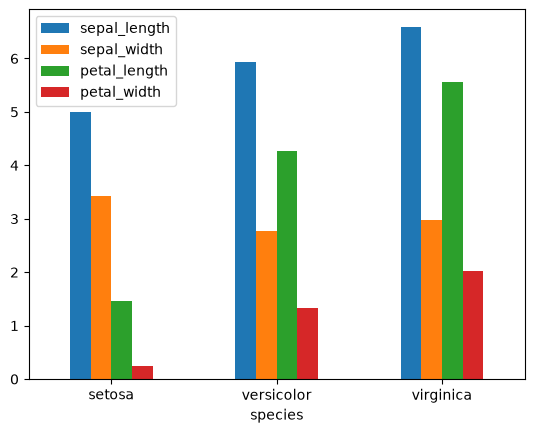

In [35]:
iris_means.plot.bar(rot=0)
plt.show()

We can also combine them by stacking if we set `stacked = True`.

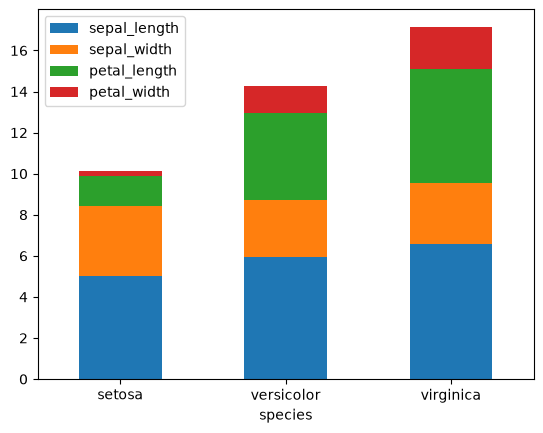

In [36]:
iris_means.plot.bar(rot=0, stacked=True)
plt.show()

Finally, we can use `subplot = True` to create a separate plot for each feature.

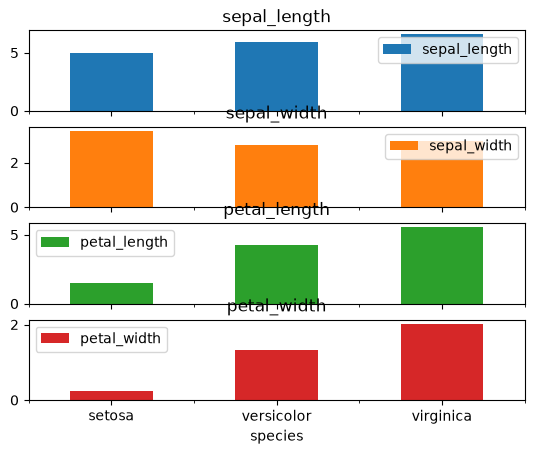

In [37]:
iris_means.plot.bar(rot=0, subplots=True)
plt.show()

Notice that this figure needs some work to improve its legibility.

Let's change the size of the figure to give each plot more room. 

To do this, we set `figsize = (5,10)`, i.e. we set width to $5$ and height to $10$. 

We can also set `plt.tight_layout()`, which adds spacing between the plots.

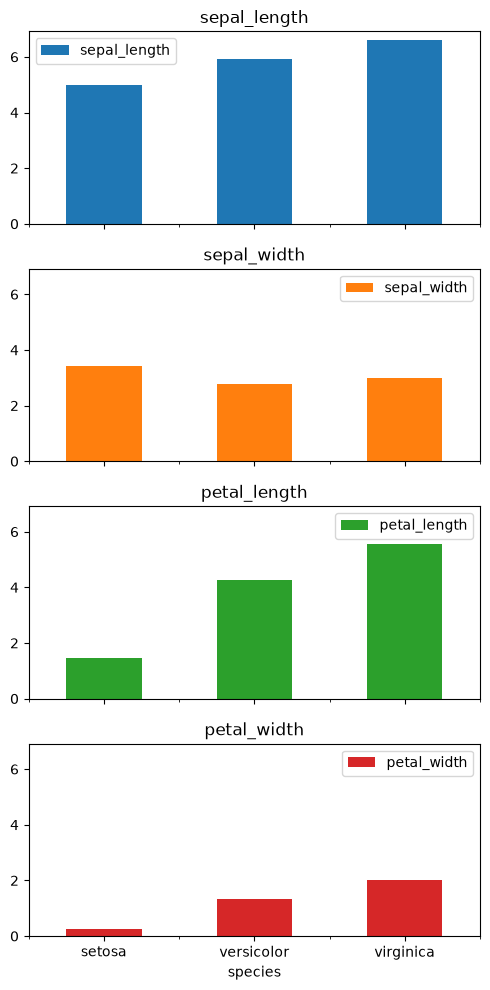

In [38]:
iris_means.plot.bar(rot=0, subplots=True, figsize=(5,10), sharey=True)
plt.tight_layout()
plt.show()

## Changing category order

Finally, we can transpose the table to change the priority of categories.

The order of representation is as follows: Each observation row gets a bar, and each feature column gets a plot.

So, if we want each species to get its own plot with features as bars, we can use the `.T` operator to flip the table.

In [40]:
iris_means.T

species,setosa,versicolor,virginica
sepal_length,5.006,5.936,6.588
sepal_width,3.428,2.770,2.974
petal_length,1.462,4.260,5.552
petal_width,0.246,1.326,2.026


The result is a different bar plot:

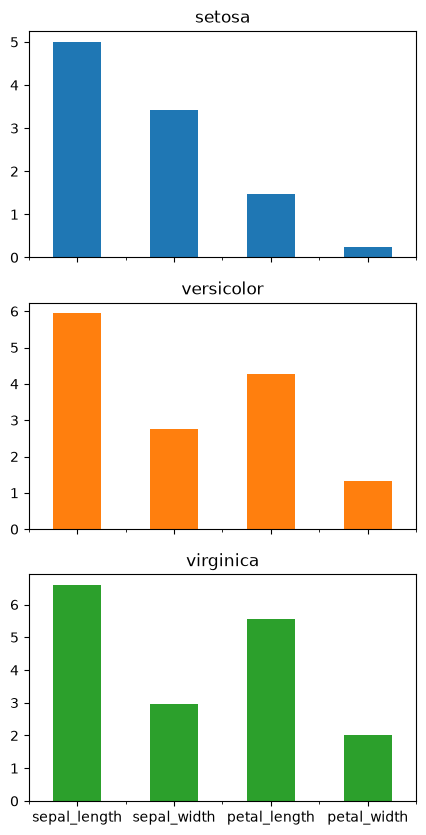

In [41]:
iris_means.T.plot.bar(rot=0, subplots=True, figsize=(5,10), legend=False)
plt.show()

Of course, we can recreate the plots we made above with the new transposed table.

This plot shows the relative magnitudes of each measurement over species.

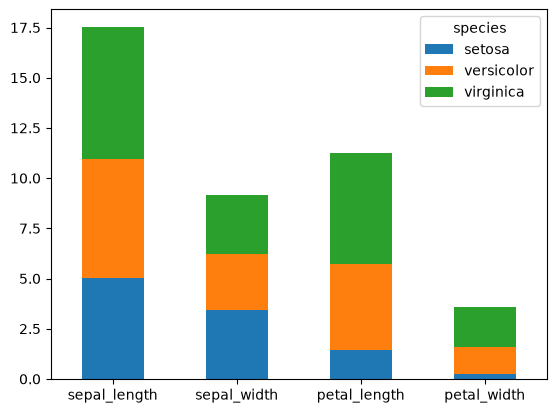

In [42]:
iris_means.T.plot.bar(rot=0, stacked=True)
plt.show()

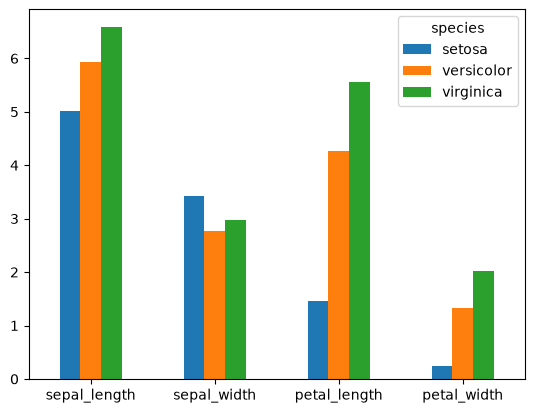

In [43]:
iris_means.T.plot.bar(rot=0, stacked=False)
plt.show()